In [134]:
import mesa_reader as mr 
import numpy as np
import matplotlib.pyplot as plt
import mesaPlot as mp
from scipy.interpolate import interp1d
from matplotlib.colors import LinearSegmentedColormap
import json
from matplotlib.colors import SymLogNorm
import copy

plt.rcParams["mathtext.fontset"] = "cm"     # to use Latex in plots

# Set the font family to Times New Roman
plt.rcParams['font.family'] = 'serif'  # Set to serif to allow flexibility
plt.rcParams['font.serif'] = ['Times New Roman']  # Set specific serif font
plt.rcParams['font.size'] = 14  # Adjust as necessary

In [2]:
#constants

G_const = 6.6743 * pow(10,-8)                 #g^-1 cm^3 s^-2 
M_sun = 1.9891 * pow(10,33)             #g
R_sun = 6.957 * pow(10,10)              #cm
c = 3 * pow(10,10)                      #cm s^-1


#model parameters

M_ns = 1.33 * M_sun                     #g
R_ns = 1000000                          #cm
f0 = 250                                #Hz
omega0 = f0*2*np.pi                     #Hz
e0 = 0.177
p_0 = 1/f0                               #s

eta1 = 1
eta2 = 0.1
alpha_ce = 1
R_eq = 10**6                            #cm
R_const = (8.31 * 10**7) / (6.022 * 10**(23)) #erg/K

#conversions

s_to_yr = 3.17098 * pow(10,-8)
yr_to_s = 3.154 * 10**7
pc_to_cm = 3.086 * pow(10,18)
D = 2.8*1000*pc_to_cm

plt.rcParams['text.usetex'] = False

m = mp.MESA()
p = mp.plot()
m.log_fold = '/home/abha2208/CE_GW/Dynamic_Envelope/my_directories/hllc/hllc_work_curr/FOLDERS/LOGS_FILES/yes_mass_loss/LOGS_12M_170724'
m.loadHistory()
m.loadProfile(num = 1)
p.plotKip3(m, plot_type='profile', xaxis = 'star_age', yaxis = 'logR', zaxis = 'total_energy')

In [314]:
plt.rcParams['text.usetex'] = False

def plot_variable_grid(
        fig, ax, xaxis, yaxis, zaxis, 
        common_ygrid=None, xlabel = 'Independent Variable', 
        ylabel = 'Coordinate', title = 'Variable Grid Plot', 
        xlim = None, ylim = None, xscale = False, yscale = False, 
        cbar = 'viridis', cmin = None, cmax = None, exclude = False, 
        exwhat = None, symlog=False, linthresh=1e-3, linscale=1.0):
    """
    Plot a diagram with variable grid spacings.

    Parameters:
    - xaxis: List or array of time steps or independent variables.
    - yaxis: List of arrays, each containing coordinate values for each time step.
    - zaxis: List of arrays, each containing values corresponding to the coordinates for each time step.
    - common_ygrid: Optional array specifying a common grid for interpolation. If None, the function will create one.
    """
    if common_ygrid is None:
        all_coords = np.concatenate(yaxis)
        common_ygrid = np.linspace(np.min(all_coords), np.max(all_coords), 5000)
    
    interp_vals = []
    for i in range(len(xaxis)):
        max_coord = np.max(xaxis[i])

        interp_func = interp1d(yaxis[i], zaxis[i], kind='nearest', bounds_error=False, fill_value=np.nan)
        
        # interp_row = interp_func(common_ygrid)
        # interp_row[common_ygrid > max_coord] = np.nan

        interp_vals.append(interp_func(common_ygrid))

    vals_matrix = np.vstack(interp_vals)

    if exclude:
        vals_matrix = np.ma.masked_where(vals_matrix == exwhat, vals_matrix)

    if cmin is not None or cmax is not None:
        vals_matrix = np.clip(vals_matrix, cmin, cmax)

    if cmin is None:
        cmin = np.nanmin(vals_matrix)
    if cmax is None:
        cmax = np.nanmax(vals_matrix)

    contour = ax.contourf(xaxis, common_ygrid, vals_matrix.T, extend='both', cmap=cbar, levels=100, vmin=cmin, vmax=cmax)
    
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12, length=4)
    ax.tick_params(axis='both', which='minor', labelsize=12, length=3)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    if xscale:
        ax.set_xscale(xscale)
    if yscale:
        ax.set_yscale(yscale)

    plt.colorbar(contour)

def replace_line_in_file(file_path, line_number, new_line):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    if line_number < len(lines):
        lines[line_number] = new_line + '\n'  # Replace the specified line

        # Write the updated lines back to the file
        with open(file_path, 'w') as f:
            f.writelines(lines)
    else:
        print(f"Error: {file_path} has fewer than {line_number+1} lines.")
    

# NOV 5

In [143]:
logs_path = 'C:/Users/abhav/Documents/UIUC_Graduate/Research/CE_GW/Temp_cluster_scp/LOGS'
logs_data = mr.MesaLogDir(logs_path)
h_data = logs_data.history_data
p_index_data = logs_data.profiles
mtotal = h_data.star_mass[0]

In [169]:
key = logs_data.profile_data(1).bulk_names
print(len(key))

45


In [394]:
q = 40
profile_num = np.arange(1, 193)
# profile_num = np.array([457, 475, 500, 525, 557])
xvals = np.array([])
yvals = []
zvals = []
zvals_2 = []
mass_90 = []
mass_92 = []
mass_94 = []
mass_98 = []
mass_99 = []
mass_995 = []
for i in profile_num:
    profile = logs_data.profile_data(profile_number=i)
    xvals = np.append(xvals, profile.star_age)
    temp = 10**profile.logR
    yvals.append(temp.tolist())
    # z_safe = np.where(profile.extra_heat== 0, np.nan, profile.extra_heat)
    # v_esc = np.sqrt(2*G_const*profile.mass*M_sun/((10**profile.logR)*R_sun))
    # zvals.append(np.log10(np.cumsum(10**profile.logRho*profile.opacity*profile.dr)))

    temp2 = profile.data(key[q])
    temp3 = -profile.data(key[q])
    # temp2 = np.log10(profile.data(key[q]))
    # temp2 = np.abs(profile.data(key[q]))
    # ignore values that are zero or negative for log scale
    # temp2 = np.where(profile.data(key[q]) <= 0, np.nan, temp2)
    temp2 = np.log10(np.where(profile.data(key[q]) <= 0, np.nan, temp2))
    temp3 = np.log10(np.where(-profile.data(key[q]) <= 0, np.nan, temp3))

    # temp_lum = profile.luminosity

    # invalid = ~np.isfinite(temp_lum) | (temp_lum <= 0)

    # if np.any(invalid):
    #     print(f"\nProfile {i}: invalid luminosity values found")
    #     print("Indices:", np.where(invalid)[0])
    #     print("Values:", temp_lum[invalid])
    zvals.append(temp2.tolist())
    # temp3 = np.log10(-profile.data(key[q]))
    # zvals_2.append(temp3.tolist())
    temp_mass = np.where(profile.mass < 0.9*mtotal)[0][0]
    mass_90.append(profile.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.92*mtotal)[0][0]
    mass_92.append(profile.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.94*mtotal)[0][0]
    mass_94.append(profile.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.98*mtotal)[0][0]
    mass_98.append(profile.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.99*mtotal)[0][0]
    mass_99.append(profile.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.995*mtotal)[0][0]
    mass_995.append(profile.logR[temp_mass])


v_div_vesc


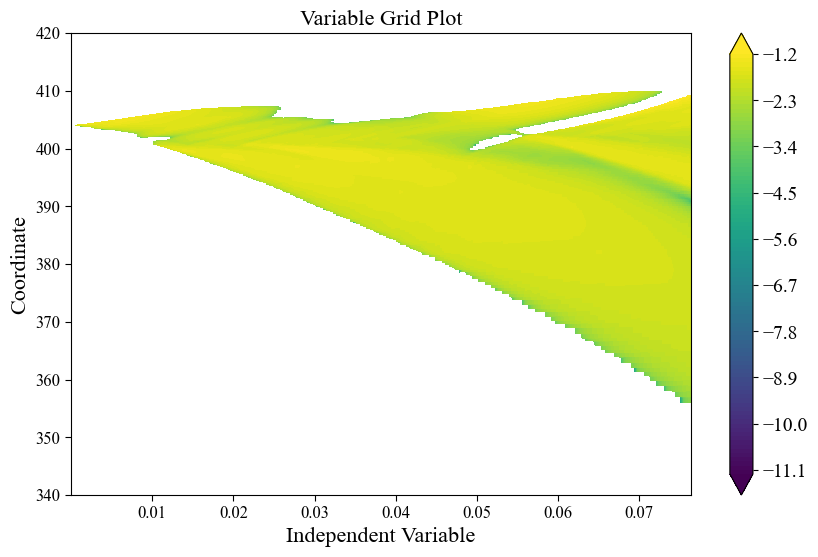

In [397]:
fig, ax = plt.subplots(figsize=(10, 6))
# fig2, ax2 = plt.subplots(figsize=(10, 6))
print(key[q])
plot_variable_grid(fig, ax, xvals, yvals, zvals, ylim=(340, 420))#, cmin=-1.6, cmax=0.3)
# plot_variable_grid(fig, ax, xvals, yvals, zvals_2, ylim=(340, 420))#, cmin=-15, cmax=0)#, symlog=True)#, title='T', xlabel='Time (yr)')#, cbar = 'viridis', cmin = 3, cmax = 5) 
# ax.plot(h_data.star_age, h_data.aorb/R_sun, label='aorb', color='black', linestyle='--')
# plot_variable_grid(fig2, ax2, xvals, yvals, zvals_2)#, cbar = 'plasma', cmin = 0, cmax = 15) 

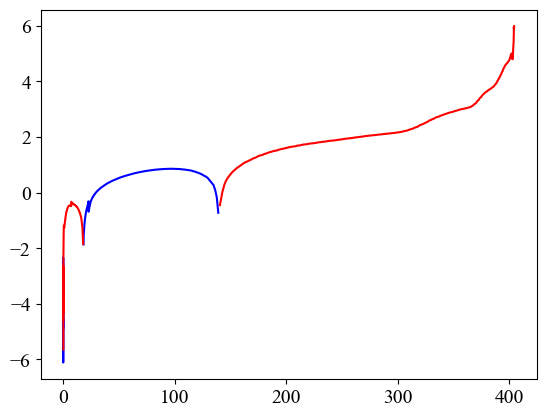

In [303]:
profile_new = mr.MesaData('C:/Users/abhav/Documents/UIUC_Graduate/Research/CE_GW/MESA_Files/LOGS_12M_11yr/profile_new.data')
mask = np.where(profile_new.velocity > 0)[0]
mask_neg = np.where(profile_new.velocity < 0)[0]
velocity_neg = copy.deepcopy(profile_new.velocity)
velocity_neg[mask] = np.nan
velocity_pos = copy.deepcopy(profile_new.velocity)
velocity_pos[mask_neg] = np.nan

plt.plot(10**profile_new.logR, np.log10(velocity_pos), label='Positive Velocity', color='blue')
plt.plot(10**profile_new.logR, np.log10(-velocity_neg), label='Negative Velocity', color='red')


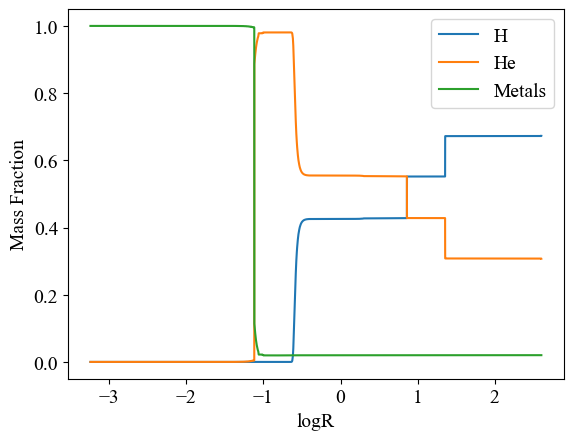

In [297]:
plt.plot(logs_data.profile_data(1).logR, logs_data.profile_data(1).x_mass_fraction_H, label='H')
plt.plot(logs_data.profile_data(1).logR, logs_data.profile_data(1).y_mass_fraction_He, label='He')
plt.plot(logs_data.profile_data(1).logR, logs_data.profile_data(1).z_mass_fraction_metals, label='Metals')
plt.xlabel('logR')
plt.ylabel('Mass Fraction')
plt.legend()
plt.show()
plt.close()

ValueError: x and y arrays must be equal in length along interpolation axis.

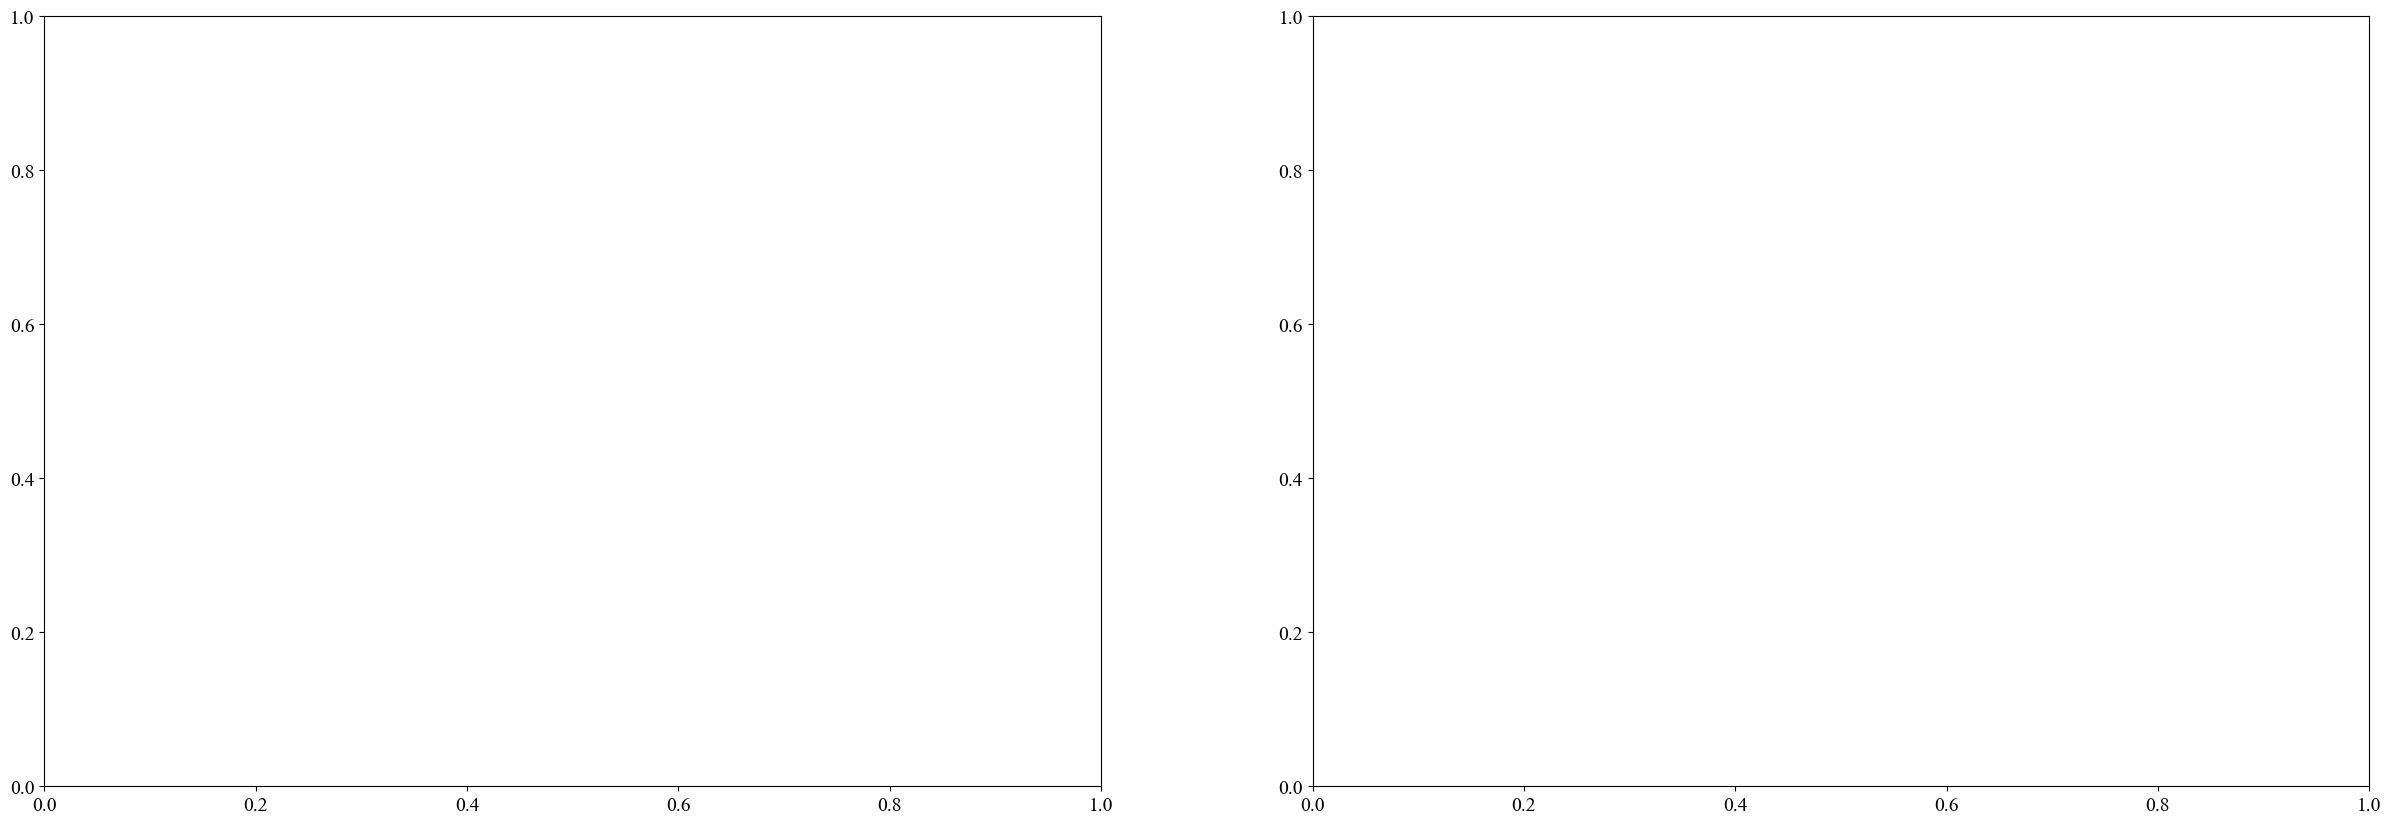

In [11]:
plt.rcParams['text.usetex'] = False

fig, ax = plt.subplots(1, 2, figsize=(30, 10))
# ax[0].plot(h_data.star_age, h_data.a_curr/R_sun, label=r'$a$', color='black', linewidth=1, zorder=5)
# ax[0].plot(h_data.star_age, h_data.r1/R_sun, label = r'$r_1$', color = 'black', linewidth = 1, zorder = 5, linestyle = '-.')
# ax[0].plot(h_data.star_age, h_data.r2/R_sun, label = r'$r_2$', color = 'black', linewidth = 1, zorder = 5, linestyle = '--')
# plot_variable_grid(fig, ax, xvals, yvals, zvals, cbar = 'seismic', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[3.5, 1200], xlim = [0.01, 4.25], ylog=False, cmin = -5e6, cmax = 5e6)#, exclude = True, exwhat = 0)#, xlim = [1,2]) for velocity
# plot_variable_grid(fig, ax, xvals, yvals, zvals, cbar = 'viridis', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[2.5, 1200], xlim = [0.01, 4.25], ylog=False, cmin = 5, cmax = 8)    #for csound
# plot_variable_grid(fig, ax, xvals, yvals, zvals, cbar = 'viridis', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[2.5, 1200], xlim = [0.01, 4.25], ylog=False)#, cmin = 5, cmax = 8)   #for extra_heat
plot_variable_grid(fig, ax[0], xvals, yvals, zvals, cbar = 'seismic', xlabel='t(yr)', ylabel=r'R ($R_\odot$)', title=r'$log(\rho)$ (cgs)', ylim=[0, 600], xlim = [0.48, 0.55])#, ylog=False, cmin = 30, cmax = 38)
ax[0].plot(xvals, 10**np.array(mass_90), color = 'white', linewidth = 1, linestyle = '--')
ax[0].plot(xvals, 10**np.array(mass_92), color = 'white', linewidth = 1, linestyle = '--')
ax[0].plot(xvals, 10**np.array(mass_94), color = 'white', linewidth = 1, linestyle = '--')
ax[0].plot(xvals, 10**np.array(mass_98), color = 'white', linewidth = 1, linestyle = '--')
ax[0].plot(xvals, 10**np.array(mass_99), color = 'white', linewidth = 1, linestyle = '--')
ax[0].plot(xvals, 10**np.array(mass_995), color = 'white', linewidth = 1, linestyle = '--')
ax[0].fill_between(h_data.star_age, h_data.r1/R_sun, h_data.r2/R_sun, where=None, color = 'grey', alpha = 0.2)
# ax[0].text(1.42, 560, '  99.9%')
# ax[0].text(1.42, 500, '  99%')
# ax[0].text(1.42, 420, '  98%')
# ax[0].text(1.42, 285, '  94%')
# ax[0].text(1.42, 250, '  92%')
# ax[0].text(1.42, 215, '  90%')
ax[0].legend(ncol = 3, loc = 'upper left', fontsize = 18)
ax[0].set_xlabel('t (yr)', fontsize = 18)
ax[0].set_ylabel(r'R ($R_\odot$)', fontsize = 18)
ax[0].set_title(r'log($F_d$)', fontsize = 18)

ax[0].tick_params(axis='both', which='major', labelsize=18, length=4)
# ax[0].set_xscale('log')
# ax[0].set_yscale('log')

####################################################

ax[1].plot(h_data.star_age, h_data.a_curr/R_sun, label=r'$a$', color='black', linewidth=1, zorder=5)
# ax[1].plot(h_data.star_age, h_data.r1/R_sun, label = r'$r_1$', color = 'black', linewidth = 1, zorder = 5, linestyle = '-.')
# ax[1].plot(h_data.star_age, h_data.r2/R_sun, label = r'$r_2$', color = 'black', linewidth = 1, zorder = 5, linestyle = '--')
# plot_variable_grid(fig, ax, xvals, yvals, zvals_2, cbar = 'seismic', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[3.5, 1200], xlim = [0.01, 4.25], ylog=False, cmin = -5e6, cmax = 5e6)#, exclude = True, exwhat = 0)#, xlim = [1,2]) for velocity
# plot_variable_grid(fig, ax, xvals, yvals, zvals_2, cbar = 'viridis', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[2.5, 1200], xlim = [0.01, 4.25], ylog=False, cmin = 5, cmax = 8)    #for csound
# plot_variable_grid(fig, ax, xvals, yvals, zvals_2, cbar = 'viridis', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[2.5, 1200], xlim = [0.01, 4.25], ylog=False)#, cmin = 5, cmax = 8)   #for extra_heat
plot_variable_grid(fig, ax[1], xvals, yvals, zvals_2, cbar = 'seismic', xlabel='t(yr)', ylabel=r'R ($R_\odot$)', title=r'$log(\rho)$ (cgs)', ylim=[0, 100], xlim = [0.48, 0.55], ylog=False, cmin = 1, cmax = 7)
ax[1].plot(xvals, 10**np.array(mass_90), color = 'white', linewidth = 1, linestyle = '--')
ax[1].plot(xvals, 10**np.array(mass_92), color = 'white', linewidth = 1, linestyle = '--')
ax[1].plot(xvals, 10**np.array(mass_94), color = 'white', linewidth = 1, linestyle = '--')
ax[1].plot(xvals, 10**np.array(mass_98), color = 'white', linewidth = 1, linestyle = '--')
ax[1].plot(xvals, 10**np.array(mass_99), color = 'white', linewidth = 1, linestyle = '--')
ax[1].plot(xvals, 10**np.array(mass_995), color = 'white', linewidth = 1, linestyle = '--')
ax[1].fill_between(h_data.star_age, h_data.r1/R_sun, h_data.r2/R_sun, where=None, color = 'grey', alpha = 0.2)
# ax[1].text(1.42, 560, '  99.9%')
# ax[1].text(1.42, 500, '  99%')
# ax[1].text(1.42, 420, '  98%')
# ax[1].text(1.42, 285, '  94%')
# ax[1].text(1.42, 250, '  92%')
# ax[1].text(1.42, 215, '  90%')
ax[1].legend(ncol = 3, loc = 'upper left', fontsize = 18)
ax[1].set_xlabel('t (yr)', fontsize = 18)
ax[1].set_ylabel(r'R ($R_\odot$)', fontsize = 18)
ax[1].set_title(r'log($\rho$)', fontsize = 18)

ax[1].tick_params(axis='both', which='major', labelsize=18, length=4)
# ax[1].set_xscale('log')
# ax[1].set_yscale('log')


plt.show()
plt.close()

In [8]:
txt = '                                    zone                                     mass                                     logR                                     logT                                   logRho                                     logP                        x_mass_fraction_H                       y_mass_fraction_He                   z_mass_fraction_metals                                       dm                                 velocity                             scale_height                    pressure_scale_height                                       dr                                dr_div_cs                          acoustic_radius                       cell_collapse_time                     compression_gradient                                   energy                                  entropy                                    grada                                   csound                                 v_div_cs                  thermal_time_to_surface                                       pp                                      cno                                tri_alpha                                  opacity                               luminosity                             total_energy                         cell_specific_IE                         cell_specific_KE                        total_energy_sign                        mlt_mixing_length                                 conv_vel                                    gradT                                    gradr                                      tau                                    omega                                        v                               v_div_vesc                                        u                                   u_face                               extra_heat                                  extra_L                                  mdot_hl                                mdot_mr15                                     mdot                                    fd_hl                                  fd_mr15                                       fd                                  edot_hl                                     edot                                  eps_rho                                     v_ns                                       Ra                                     Eorb                                    dEorb                                        f '
line_num = 5
def replace_line_in_file(file_path, line_number, new_line):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    if line_number < len(lines):
        lines[line_number] = new_line + '\n'  # Replace the specified line

        # Write the updated lines back to the file
        with open(file_path, 'w') as f:
            f.writelines(lines)
    else:
        print(f"Error: {file_path} has fewer than {line_number+1} lines.")
for i in range(480,485):
    file_path = '/home/abha2208/CE_GW/Dynamic_Envelope/my_directories/hllc_cluster/run11/LOGS/profile' + str(i) + '.data'
    replace_line_in_file(file_path, line_num, txt)

In [76]:
logs_path_temp = '/home/abha2208/CE_GW/Dynamic_Envelope/my_directories/hllc_cluster/run11/LOGS'
logs_data_temp = mr.MesaLogDir(logs_path_temp)
h_data_temp = logs_data_temp.history_data
p_index_data_temp = logs_data_temp.profiles
mtotal_temp = h_data_temp.star_mass[0]

In [80]:
profile_num_temp = np.arange(1, 1145)
xvals_temp = np.array([])
yvals_temp = []
zvals_temp = []
mass_90_temp = []
mass_92_temp = []
mass_94_temp = []
mass_98_temp = []
mass_99_temp = []
mass_995_temp = []
for i in profile_num_temp:
    profile_temp = logs_data_temp.profile_data(profile_number=i)
    xvals_temp = np.append(xvals_temp, profile_temp.star_age)
    yvals_temp.append(10**profile_temp.logR)
    # z_safe = np.where(profile.extra_heat== 0, np.nan, profile.extra_heat)
    v_esc_temp = np.sqrt(2*G_const*profile_temp.mass*M_sun/((10**profile_temp.logR)*R_sun))
    # zvals.append(np.log10(np.cumsum(10**profile.logRho*profile.opacity*profile.dr)))
    zvals_temp.append(profile_temp.logRho)
    temp_mass = np.where(profile_temp.mass < 0.9*mtotal_temp)[0][0]
    mass_90_temp.append(profile_temp.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.92*mtotal)[0][0]
    mass_92_temp.append(profile_temp.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.94*mtotal)[0][0]
    mass_94_temp.append(profile_temp.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.98*mtotal)[0][0]
    mass_98_temp.append(profile_temp.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.99*mtotal)[0][0]
    mass_99_temp.append(profile_temp.logR[temp_mass])
    temp_mass = np.where(profile.mass < 0.995*mtotal)[0][0]
    mass_995_temp.append(profile_temp.logR[temp_mass])

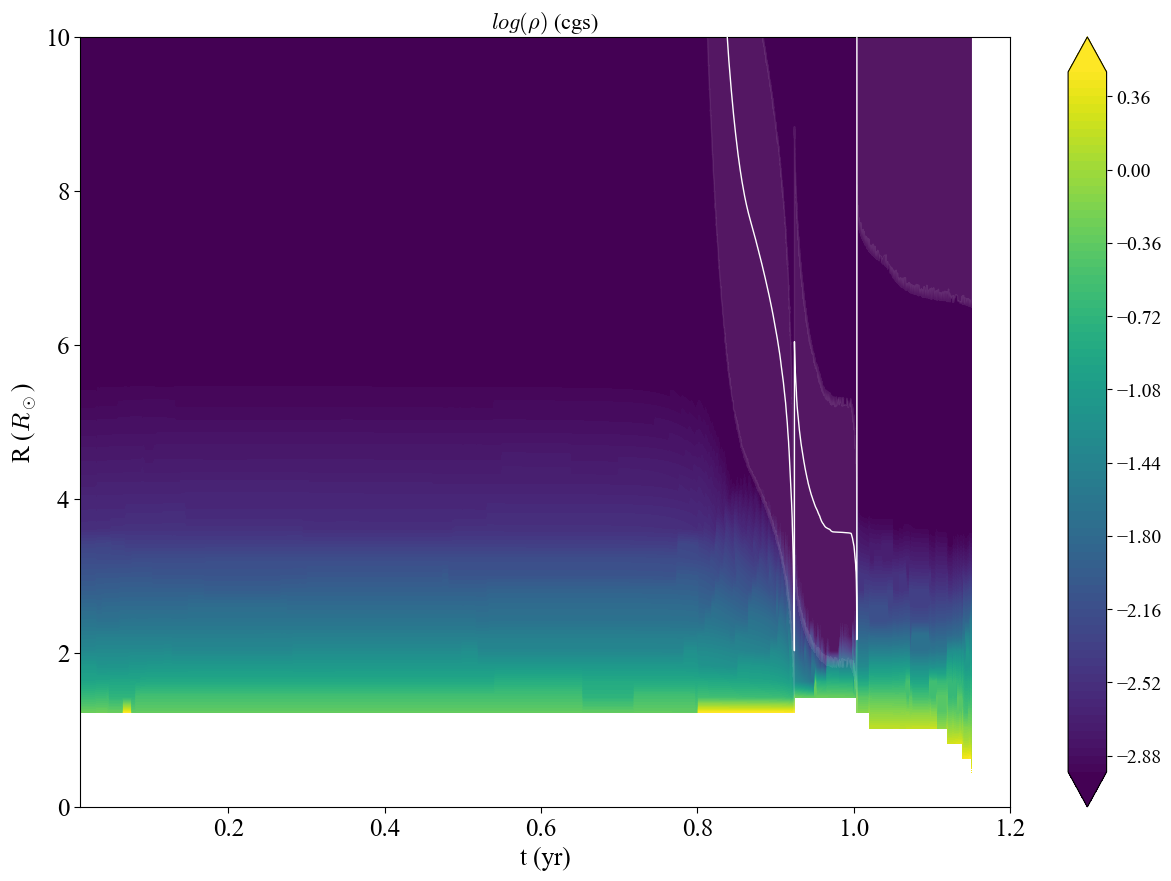

In [82]:
plt.rcParams['text.usetex'] = False

fig, ax = plt.subplots(figsize=(15, 10))
ax.plot(h_data_temp.star_age, h_data_temp.a_curr/R_sun, label=r'$a$', color='white', linewidth=1, zorder=5)
# plt.plot(h_data.star_age, h_data.r1/R_sun, label = r'$r_1$', color = 'black', linewidth = 1, zorder = 5, linestyle = '-.')
# plt.plot(h_data.star_age, h_data.r2/R_sun, label = r'$r_2$', color = 'black', linewidth = 1, zorder = 5, linestyle = '--')
# plot_variable_grid(fig, ax, xvals, yvals, zvals, cbar = 'seismic', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[3.5, 1200], xlim = [0.01, 4.25], ylog=False, cmin = -5e6, cmax = 5e6)#, exclude = True, exwhat = 0)#, xlim = [1,2]) for velocity
# plot_variable_grid(fig, ax, xvals, yvals, zvals, cbar = 'viridis', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[2.5, 1200], xlim = [0.01, 4.25], ylog=False, cmin = 5, cmax = 8)    #for csound
# plot_variable_grid(fig, ax, xvals, yvals, zvals, cbar = 'viridis', xlabel='Star Age', ylabel='R', title='log(eps_rho)', ylim=[2.5, 1200], xlim = [0.01, 4.25], ylog=False)#, cmin = 5, cmax = 8)   #for extra_heat
plot_variable_grid(fig, ax, xvals_temp, yvals_temp, zvals_temp, cbar = 'viridis', xlabel='t(yr)', ylabel=r'R ($R_\odot$)', title=r'$log(\rho)$ (cgs)', ylim=[0, 1000], xlim = [0.01, 1.2], ylog=False, cmin = -3, cmax = 0.5)
# plt.plot(np.repeat(0.75, 100), np.linspace(0, 500, 100), color = 'white', linewidth = 1, linestyle = '--')
# plt.plot(np.repeat(0.65, 100), np.linspace(0, 500, 100), color = 'white', linewidth = 1, linestyle = '--')

plt.plot(xvals_temp, 10**np.array(mass_90_temp), color = 'white', linewidth = 1, linestyle = '--')
plt.plot(xvals_temp, 10**np.array(mass_92_temp), color = 'white', linewidth = 1, linestyle = '--')
plt.plot(xvals_temp, 10**np.array(mass_94_temp), color = 'white', linewidth = 1, linestyle = '--')
plt.plot(xvals_temp, 10**np.array(mass_98_temp), color = 'white', linewidth = 1, linestyle = '--')
plt.plot(xvals_temp, 10**np.array(mass_99_temp), color = 'white', linewidth = 1, linestyle = '--')
plt.plot(xvals_temp, 10**np.array(mass_995_temp), color = 'white', linewidth = 1, linestyle = '--')
plt.fill_between(h_data_temp.star_age, h_data_temp.r1/R_sun, h_data_temp.r2/R_sun, where=None, color = 'white', alpha = 0.09)
# plt.text(1.42, 560, '  99.9%')
# plt.text(1.42, 500, '  99%')
# plt.text(1.42, 420, '  98%')
# plt.text(1.42, 285, '  94%')
# plt.text(1.42, 250, '  92%')
# plt.text(1.42, 215, '  90%')
# plt.legend(ncol = 3, loc = 'upper left', fontsize = 18)
plt.xlabel('t (yr)', fontsize = 18)
plt.ylabel(r'R ($R_\odot$)', fontsize = 18)
# plt.title(r'$log_{10}(\dot{M})$', fontsize = 18)
plt.tick_params(axis='both', which='major', labelsize=18, length=4)
# ax.set_xscale('log')
# ax.set_yscale('log')
plt.ylim([0, 10])
plt.show()
plt.close()